In [46]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

#carregando o dataset
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
def load_oasis_data(path = OASIS_PREPARED_PATH):
    return pd.read_csv(path)

data = load_oasis_data()

#dividindo em X e y
X = data.drop(columns=['Risk.Group'])
y = data['Risk.Group']

print("Dimensões de X: ", X.shape)
print(pd.Series(y).value_counts())

Dimensões de X:  (5150, 8)
Risk.Group
1    2578
0    2572
Name: count, dtype: int64


In [47]:
#fazendo divisão estratificada entre dados de treino e dados de teste pelo train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#fazendo o preenchimento dos valores nulos dos dados após fazer o Holdout para não haver data leakage
imp = SimpleImputer(missing_values=np.nan, strategy='median')
imp.set_output(transform='pandas')

X_train_imp = imp.fit_transform(X_train)
#aprender e aplicar no treino e apenas aplicar no teste
X_test_imp = imp.transform(X_test)

print(X_train_imp.info())


<class 'pandas.core.frame.DataFrame'>
Index: 3605 entries, 1114 to 1423
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         3605 non-null   float64
 1   EDUC        3605 non-null   float64
 2   SES         3605 non-null   float64
 3   MMSE        3605 non-null   float64
 4   CDR         3605 non-null   float64
 5   eTIV        3605 non-null   float64
 6   nWBV        3605 non-null   float64
 7   Gender.Num  3605 non-null   float64
dtypes: float64(8)
memory usage: 253.5 KB
None


In [48]:
#fazendo a normalização dos dados após fazer o Holdout para não haver data leakage
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

#usando os modelos de AM que a prof mariana usou no laboratório para começar a mexer com os dados

#Treinamento 1: KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

#Treinamento 2: Árvore de Decisão
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print('Métricas KNN:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_knn):.4f} | Precision: {precision_score(y_test, y_pred_knn):.4f} | Recall: {recall_score(y_test, y_pred_knn):.4f} | F1: {f1_score(y_test, y_pred_knn):.4f}")
print('Métricas Árvore de Decisão:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.4f} | Precision: {precision_score(y_test, y_pred_dt):.4f} | Recall: {recall_score(y_test, y_pred_dt):.4f} | F1: {f1_score(y_test, y_pred_dt):.4f}")

Métricas KNN:
Accuracy: 0.9832 | Precision: 1.0000 | Recall: 0.9664 | F1: 0.9829
Métricas Árvore de Decisão:
Accuracy: 0.9676 | Precision: 0.9653 | Recall: 0.9702 | F1: 0.9677


As métricas estão bem parecidas. O recall, que é uma métrica importante para evitar falsos negativos, está com um resultado melhor com o modelo de árvore de decisão.

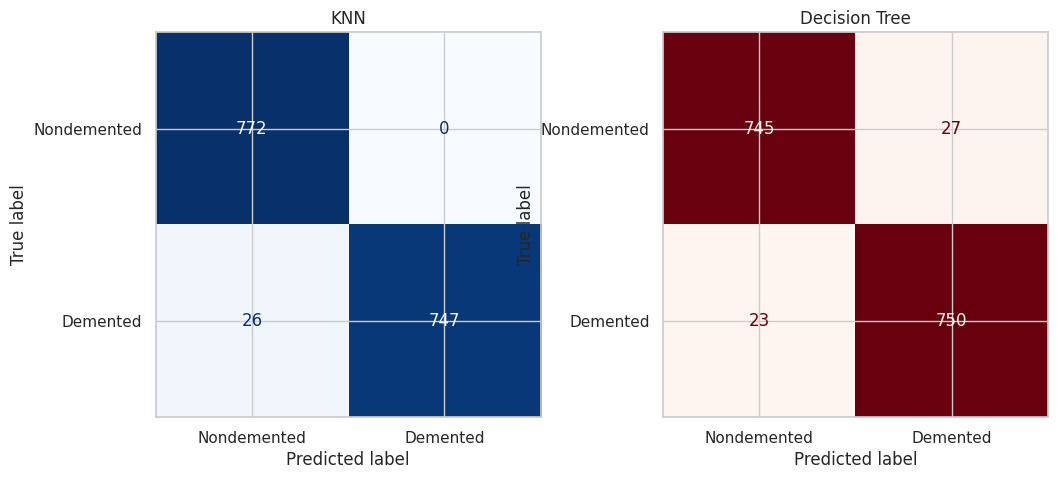

In [49]:
#criando matrizes de confusão
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['Nondemented', 'Demented'], cmap='Blues', colorbar=False, ax=ax[0])
ax[0].set_title("KNN")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['Nondemented', 'Demented'], cmap='Reds', colorbar=False, ax=ax[1])
ax[1].set_title("Decision Tree")
plt.show()

Dentre esses modelos, o melhor modelo para identificar a classe "Demented" é o Decision Tree. Isso é importante, pois precisamos deixar passar o mínimo possível de Falsos Negativos (focar em não dizer que alguém que TEM chance de ter Alzheimer NÃO tem chance de ter Alzheimer): foco na métrica "Recall".

In [50]:
#checando o overfitting

y_pred_knn_train = knn.predict(X_train_scaled)
accuracy_knn_train = accuracy_score(y_train, y_pred_knn_train)
accuracy_knn_test = accuracy_score(y_test, y_pred_knn)
print(f"KNN Train Accuracy: {accuracy_knn_train:.4f} | KNN Test Accuracy: {accuracy_knn_test:.4f}")

y_pred_dt_train = dt.predict(X_train_scaled)
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)
accuracy_dt_test = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Train Accuracy: {accuracy_dt_train:.4f} | Decision Tree Test Accuracy: {accuracy_dt_test:.4f}")

KNN Train Accuracy: 0.9834 | KNN Test Accuracy: 0.9832
Decision Tree Train Accuracy: 1.0000 | Decision Tree Test Accuracy: 0.9676


Comparando as acurácias do treino e do teste, parece que a decision tree está com overfitting. Como melhorar? Teste: definir profundidade máxima e quantidade mínima de pacientes por folha.

In [51]:
#novo treinamento para diminuir overfitting

#Treinamento 2: Árvore de Decisão
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print('Métricas Árvore de Decisão:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.4f} | Precision: {precision_score(y_test, y_pred_dt):.4f} | Recall: {recall_score(y_test, y_pred_dt):.4f} | F1: {f1_score(y_test, y_pred_dt):.4f}")

#checando o overfitting

y_pred_dt_train = dt.predict(X_train_scaled)
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)
accuracy_dt_test = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Train Accuracy: {accuracy_dt_train:.4f} | Decision Tree Test Accuracy: {accuracy_dt_test:.4f}")

Métricas Árvore de Decisão:
Accuracy: 0.9851 | Precision: 1.0000 | Recall: 0.9702 | F1: 0.9849
Decision Tree Train Accuracy: 0.9850 | Decision Tree Test Accuracy: 0.9851


A partir desses novos valores, parece não haver mais tanto overfitting.

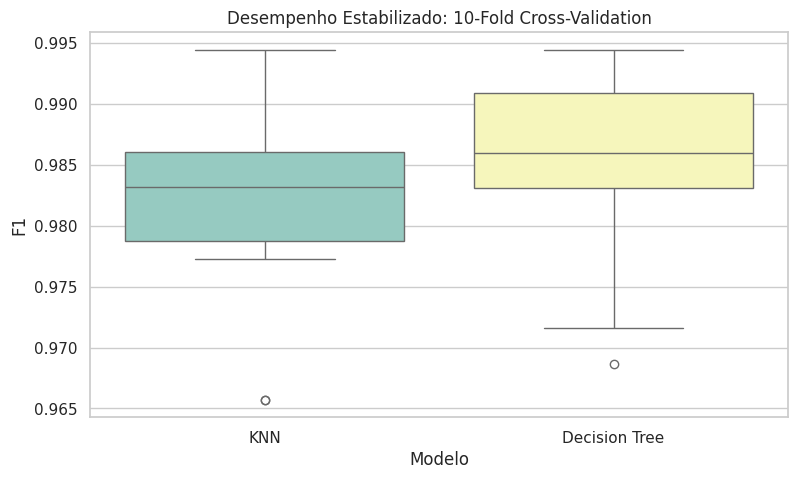

In [52]:
#fazendo o cross validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_dict = {'acuracia':'accuracy', 'precisao':'precision', 'recall':'recall', 'f1':'f1'}

#envolvendo simple imputer + scaling + classificador no pipeline

pipe_knn = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe_dt = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', MinMaxScaler()),
    ('dt', DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=cv, scoring=scoring_dict)
cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=cv, scoring=scoring_dict)

res_df = pd.DataFrame({
    'Modelo': ['KNN']*10 + ['Decision Tree']*10,
    'F1': list(cv_knn['test_f1']) + list(cv_dt['test_f1'])
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=res_df, x='Modelo', y='F1', hue='Modelo', palette='Set3', legend=False)
plt.title("Desempenho Estabilizado: 10-Fold Cross-Validation")
plt.show()

A partir deste gráfico, podemos ver que o F1 da decision tree é geralmente melhor que o do knn para os diferentes testes com os folds.